In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt
import ot 
import scipy as sp
from risgw import risgw_gpu
from sgw_numpy import sgw_cpu
import torch
from SEINT.SEINT_numpy import SEINT

    

def RISGW(X, Y):
    n, p = np.shape(X)
    nproj1 =  round(np.log10(n)*10)
    device='cpu'
    dist = risgw_gpu(torch.from_numpy(X).to(torch.float32).to(device), torch.from_numpy(Y).to(torch.float32).to(device), device='cpu', nproj=nproj1)
    return dist

def GW(X, Y):
    C3 = sp.spatial.distance.cdist(X, X)
    C4 = sp.spatial.distance.cdist(Y, Y)
    C3 /= C3.max()
    C4 /= C4.max()
    p = ot.unif(len(X))
    q = ot.unif(len(Y))
    dist = ot.gromov.gromov_wasserstein(
        C3, C4, p, q, "square_loss", verbose=False, log=True)[1]["gw_dist"]
    return dist

def SEINT_Func(X, Y):
    n, p = np.shape(X)
    nproj1 =  round(np.log10(n)*10)
    dist = SEINT(X,Y,  maxed=True,set_seed = True, acc = True, rep = nproj1)
    return dist

def ISEINT(X, Y):
    n, p = np.shape(X)
    nproj1 =  round(np.log10(n)*10)
    dist = SEINT(X,Y, maxed=False, set_seed = True, acc = True, rep = nproj1)
    return dist
def sinkhorn(X, Y, reg=1e-5, p=2):
    a = ot.unif(len(X))         
    b = ot.unif(len(Y))
    M = ot.dist(X, Y, metric='euclidean') ** p  
    return ot.sinkhorn2(a, b, M, reg) ** (1.0 / p)


def emd(X, Y, p=2):
    a = ot.unif(len(X))
    b = ot.unif(len(Y))
    M = ot.dist(X, Y, metric='euclidean') ** p
    T = ot.emd(a, b, M)          
    dist = np.sum(T * M) ** (1.0 / p) 
    return dist


def SGW(X,Y):
    n, p = np.shape(X)
    nproj1 =  round(np.log10(n)*10)
    dist  = sgw_cpu(X,Y,nproj = nproj1)
    return dist 


METHODS = {
    "GW":     GW,
    "RISGW":      RISGW,
    "SGW":        SGW,
    "EMD": emd,
    "SEINT":         SEINT_Func,
    "ISEINT":  ISEINT,
}


def make_cov_matrices(theta: float, d: int):
    """
    Σ_X  = diag(3 I₂ , I_{d-2})
    Σ_Y  = diag(3 I₂ + 3 θ B₂ , I_{d-2}),  B₂ = [[0,1],[1,0]]
    """

    Sigma_X = np.eye(d)
    Sigma_X[:2, :2] = 3 * np.eye(2)

    B2 = np.array([[0., 1.],
                   [1., 0.]])
    Sigma_block = 3 * np.eye(2) + 3 * theta * B2
    Sigma_Y = np.eye(d)
    Sigma_Y[:2, :2] = Sigma_block
    return Sigma_X, Sigma_Y

def sample_gaussian(cov: np.ndarray, n: int,seed):
    np.random.seed(seed)
    return np.random.multivariate_normal(mean=np.zeros(cov.shape[0]), cov=cov, size=n)

def experiment_theta_loss(theta_list, n=200, d=50, n_trials=5):
    """
    Return:
        losses[method]  shape=(len(theta_list),)
    """
    losses_mean = {m: [] for m in METHODS}

    for theta in theta_list:
        trial_losses = {m: [] for m in METHODS}
        for _ in range(n_trials):
            Σ_X, Σ_Y = make_cov_matrices(theta, d)
            X = sample_gaussian(Σ_X, n,_*10)
            Y = sample_gaussian(Σ_Y, n,_*10)

            for name, func in METHODS.items():
                trial_losses[name].append(func(X, Y))

        for name in METHODS:
            losses_mean[name].append(np.mean(trial_losses[name]))

    return losses_mean 


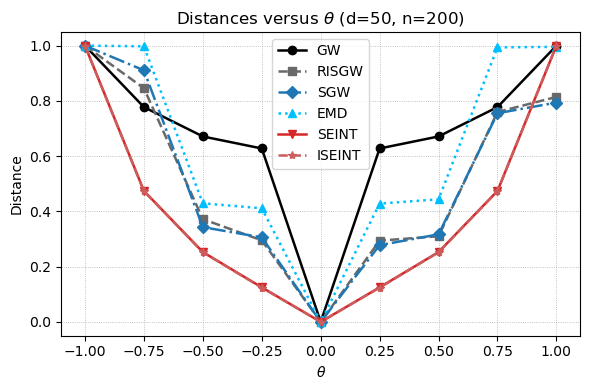

In [26]:
import numpy as np
import matplotlib.pyplot as plt
theta_vals = np.linspace(-1.0, 1.0, 9) 
loss_results = experiment_theta_loss(theta_vals)
color_cycle = [
    "black", "dimgray",       
    "tab:blue", "deepskyblue",
    "tab:red", "indianred"   
]

marker_cycle = ["o", "s", "D", "^", "v", "*"]
linestyle_cycle = ["-", "--", "-.", ":", "-", "--"]

plt.figure(figsize=(6, 4))

for idx, (name, vals) in enumerate(loss_results.items()):
    color = color_cycle[idx % len(color_cycle)]
    marker = marker_cycle[idx % len(marker_cycle)]
    ls = linestyle_cycle[idx % len(linestyle_cycle)]

    y = vals if name == "SINKHORN" else vals / max(vals)

    plt.plot(theta_vals, y,
             label=name,
             color=color,
             marker=marker,
             linestyle=ls,
             linewidth=1.8,
             markersize=6)

plt.xlabel(r'$\theta$')
plt.ylabel('Distance')
plt.title('Distances versus $\\theta$ (d=50, n=200)')
plt.grid(True, linestyle=':', linewidth=0.6)
plt.legend()
plt.tight_layout()
plt.show()